<a href="https://colab.research.google.com/github/GuiBrito218/Interfocus-Clima-Predict-POC/blob/main/trabalho_fundamentos_inteligencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Essa demonstração exploratória é a base técnica que valida a viabilidade da nossa Prova de Conceito (POC) para a Interfocus

•	Arthur Jiarduli RA:2193156
•	Davi Temporini RA:2195243
•	Guilherme Brito RA: 2199445
•	Guilherme Adriano RA:2199258
•	Giulia Giu RA:2198990



# Análise Exploratória de Dados
**Dataset:** Interrupções na Rede Elétrica dos EUA (2000–2014)  
**Fonte:** U.S. Department of Energy

Magnitude: A quantidade de energia perdida e o volume de clientes afetados.
Temporalidade: Quando as falhas ocorreram e como a frequência delas evoluiu ao longo dos anos.
Eficiência de Resposta: O tempo que se leva para restaurar o serviço (OUTAGE.DURATION).
Correlação: A ligação entre o impacto inicial (perda de carga) e a dificuldade de recuperação (tempo de reparo).

In [ ]:
import pandas as pd

# Carregamento do dataset -  Carrega o arquivo CSV do repositório GitHub para o ambiente de código
df = pd.read_csv(path + "/Grid_Disruption_00_14_standardized - Grid_Disruption_00_14_standardized.csv")





In [ ]:
# Exibição das primeiras linhas e colunas
df.head()
print(df.columns)

Index(['Event Description', 'Year', 'Date Event Began', 'Time Event Began',
       'Date of Restoration', 'Time of Restoration', 'Respondent',
       'Geographic Areas', 'NERC Region', 'Demand Loss (MW)',
       'Number of Customers Affected', 'Tags'],
      dtype='object')


In [ ]:
# Limpeza e conversão de datas com proteção contra erro
df['Date Event Began'] = pd.to_datetime(df['Date Event Began'], errors='coerce')
df['Date of Restoration'] = pd.to_datetime(df['Date of Restoration'], errors='coerce')


In [ ]:

# Criação da variável de duração da falha (em horas) Cria a nova variável 'OUTAGE.DURATION' calculando a diferença entre o fim e o início da falha
# O resultado é dividido por 3600 para termos a duração em HORAS
df['OUTAGE.DURATION'] = (df['Date of Restoration'] - df['Date Event Began']).dt.total_seconds() / 3600

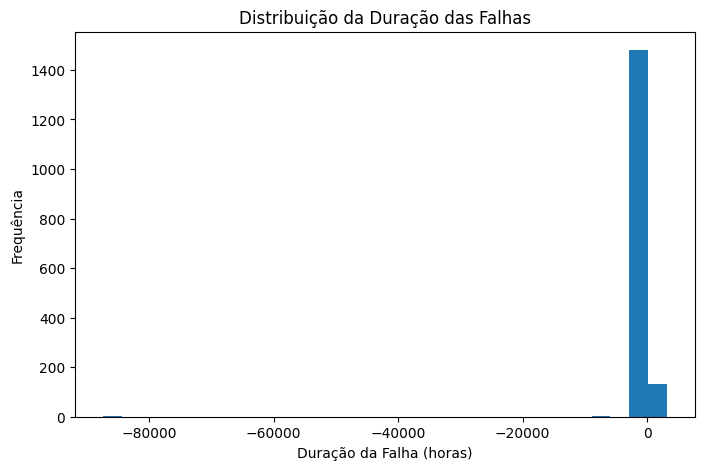

In [ ]:
# Visualização de Dados
import matplotlib.pyplot as plt
# Gera o Histograma para ver a distribuição das falhas
plt.figure(figsize = (8, 5))
plt.hist(df['OUTAGE.DURATION'].dropna(), bins = 30)
plt.title('Distribuição da Duração das Falhas')
plt.xlabel('Duração da Falha (horas)')
plt.ylabel('Frequência')
plt.show()
#O histograma de duração permite entender o "tempo médio de cura" da rede. Se a frequência de falhas longas for alta, significa que as equipes de campo precisam de informações precisas para agir rápido.

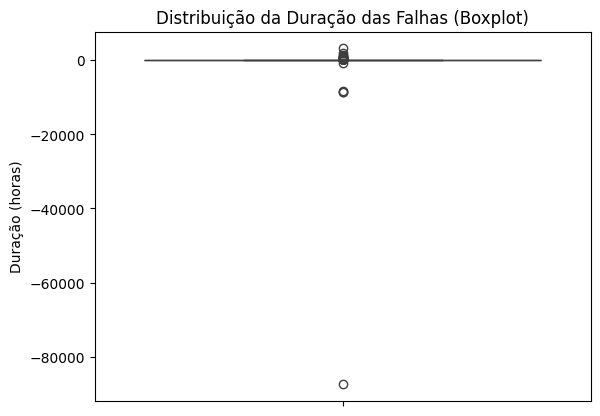

In [ ]:
#Identificação de Outliers - Gera o Boxplot para identificar pontos fora da curva (Outliers)
import seaborn as sns

sns.boxplot(y=df['OUTAGE.DURATION'])
plt.title('Distribuição da Duração das Falhas (Boxplot)')
plt.ylabel('Duração (horas)')
plt.show()
# OBSERVAÇÃO PARA INTERPRETAÇÃO: Se houver pontos muito altos acima do "caixote" são falhas catastróficas que duraram muito além do normal
#O Boxplot revela que, embora a maioria das falhas seja resolvida rapidamente, existem eventos "catastróficos" que fogem totalmente ao padrão. A IA da Interfocus focará justamente na previsão desses eventos de alto impacto, que são os que geram maior prejuízo financeiro.

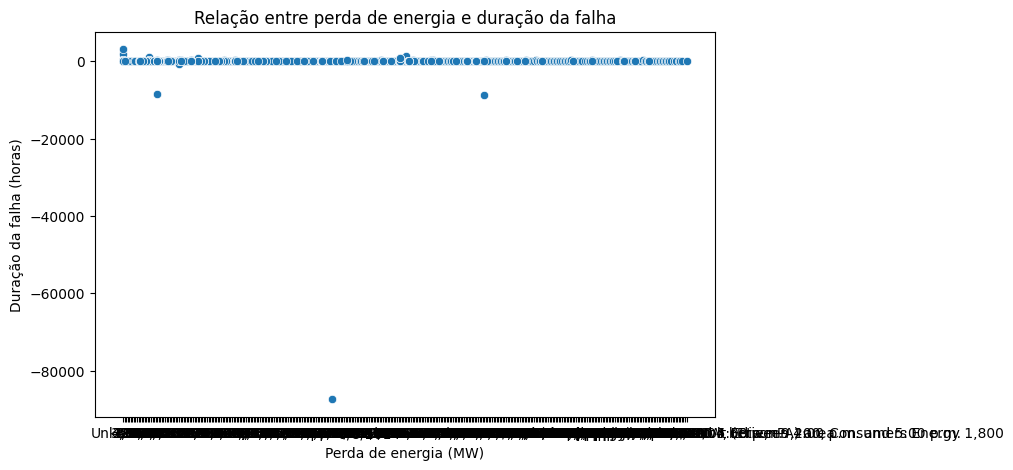

In [ ]:
#Relação Perda vs. Duração
# Mapeia a relação entre a quantidade de energia perdida e o tempo
plt.figure(figsize =(8, 5))
sns.scatterplot(x=df['Demand Loss (MW)'], y= df['OUTAGE.DURATION'])
plt.title('Relação entre perda de energia e duração da falha')
plt.xlabel('Perda de energia (MW)')
plt.ylabel('Duração da falha (horas)')
plt.show()
# CORRELAÇÃO IMPORTANTE: Observe se os pontos sobem para a direita.
# Se sim, quanto maior o estrago inicial (MW), mais tempo a equipe leva para consertar.

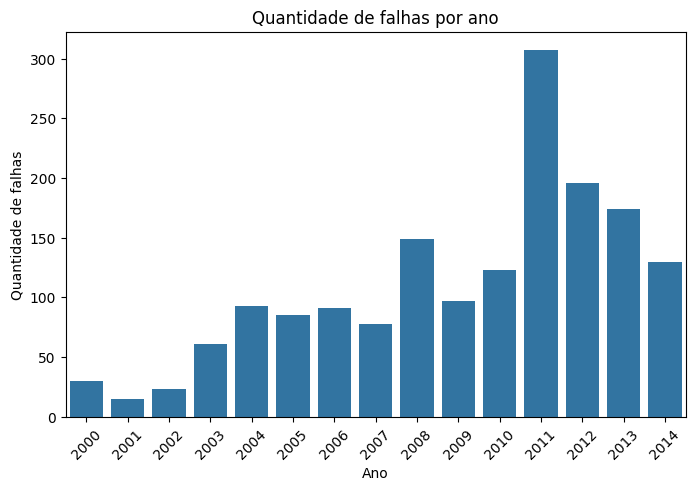

In [ ]:
#Conta quantas falhas ocorreram em cada ano do dataset
plt.figure(figsize=(8, 5))
sns.countplot(x=df['Year'])
plt.title('Quantidade de falhas por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de falhas')
plt.xticks(rotation=45)
plt.show()

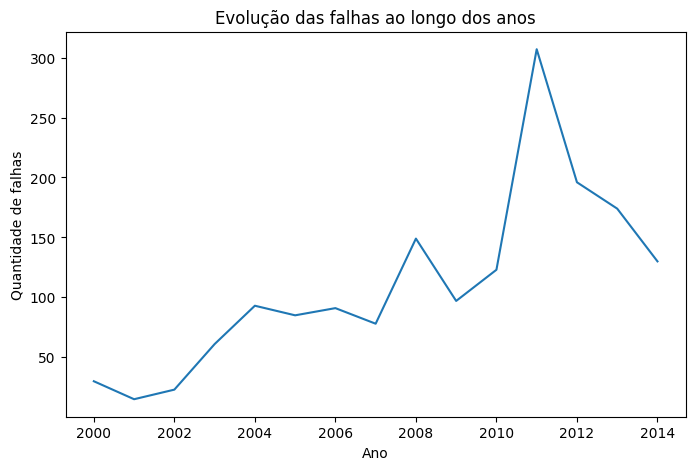

In [19]:
#Evolução Temporal -  Agrupa os dados para criar uma linha de evolução histórica
falhas_por_ano = df.groupby('Year').size()
plt.figure(figsize=(8, 5))
sns.lineplot(x=falhas_por_ano.index, y=falhas_por_ano.values)
plt.title('Evolução das falhas ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Quantidade de falhas')
plt.show()
# Uma linha ascendente justifica a solução da Interfocus,
# Prova que o problema de quedas de energia está crescendo com o tempo.
#Aumento da Vulnerabilidade: Se o gráfico de Evolução Temporal mostrar uma linha ascendente, fica provado que o sistema elétrico está se tornando mais instável. Isso justifica a necessidade urgente de uma solução de monitoramento inteligente como a da Interfocus.

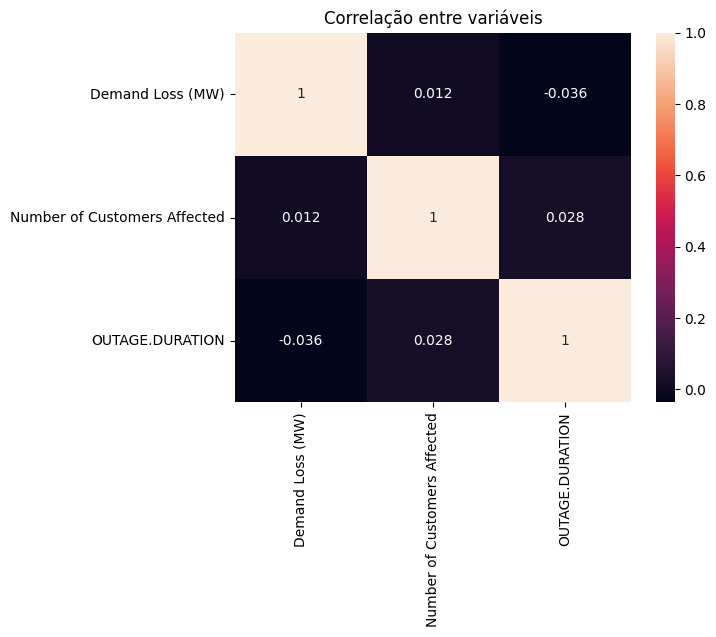

In [20]:
#Heatmap de Correlação
# Prepara as colunas convertendo-as para números para o cálculo matemático
df['Demand Loss (MW)'] = pd.to_numeric(df['Demand Loss (MW)'], errors='coerce')
df['Number of Customers Affected'] = pd.to_numeric(df['Number of Customers Affected'], errors='coerce')

# Calcula o índice de correlação entre as variáveis principais
correlacao = df[['Demand Loss (MW)', 'Number of Customers Affected', 'OUTAGE.DURATION']].corr()
# Desenha o mapa de calor com os números da correlação
sns.heatmap(correlacao, annot=True)
plt.title('Correlação entre variáveis')
plt.show()
# CORRELAÇÃO CRÍTICA: Números próximos a 1.0 indicam uma ligação forte.
# se a correlação entre Clientes Afetados e Perda (MW) for alta,
#O Heatmap de Correlação e o Scatterplot são fundamentais. Se houver uma correlação forte entre a perda de energia e a duração da falha, a POC valida que é possível prever o tempo de inatividade com base nos sinais iniciais da queda.